# Biological similarity of AssayBench screens — hit-gene Jaccard & clustering

**Goal.** Quantify biological similarity between the CRISPR screens in the main AssayBench
dataset (`Genentech/assaybench`, config `biogrid`), group screens into clusters of
biologically similar assays, and give each cluster an interpretable name.

**Approach (this notebook).**
1. Load the main dataset (all splits) and assemble one row per screen.
2. Define each screen's **hit-gene set** = genes with a non-zero relevance score
   (positive = enriched / one selection direction, negative = depleted / the other).
3. Compute pairwise **Jaccard similarity** of hit-gene sets (the requested starting point).
4. Down-weight ubiquitous core-essential genes with an **IDF-weighted Jaccard**, because raw
   Jaccard is dominated by the common-essential genes shared across most fitness screens.
5. Cluster screens with **graph community detection (Louvain)** on a k-NN similarity graph —
   the appropriate tool when similarity is sparse (most screen pairs share almost no hits).
6. **Name** each cluster from its dominant phenotype / tissue and characteristic hit genes.

**Key data facts** (verified before writing this notebook):
- 1,901 screens; relevance scores in [-1, 1]; `0` = non-hit.
- `screen_category`: 1,261 unidirectional (positive scores only), 565 bidirectional
  (both signs), 75 recovered-bidirectional.
- Median hit-set size ≈ 800 genes — large fitness screens share core essentials, which is
  why step 4 matters.

Seed fixed to 42 throughout (workspace convention).

In [1]:
from __future__ import annotations

import os
os.environ.setdefault("HF_HUB_OFFLINE", "1")  # dataset is cached locally

import collections
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, diags
import networkx as nx
from networkx.algorithms.community import louvain_communities

from assaybench import AssayBenchDataset

SEED = 42
np.random.seed(SEED)
sns.set_theme(context="notebook", style="whitegrid")

RESULTS = Path("results"); RESULTS.mkdir(exist_ok=True)
FIGURES = Path("figures"); FIGURES.mkdir(exist_ok=True)
print("setup complete")

setup complete


## 1. Load the main AssayBench dataset

We use `dataset_name="biogrid"` — the main dataset — and pull **all** screens regardless of
train/val/test split, since biological similarity is a property of the assays, not of any
modelling split. The `LaTest` novel set is intentionally excluded.

In [2]:
ds = AssayBenchDataset(
    dataset_name="biogrid",       # main dataset
    split_type="year",
    fold=0,
    novel_dataset_name=None,       # exclude the LaTest novel screens
)
examples = ds.get_list_examples()
print(f"Loaded {len(examples)} screens from the main (biogrid) dataset")

META_COLS = [
    "dataset_name", "phenotype", "cleaned_phenotype", "condition_clause",
    "cell_type", "cell_line", "screen_type", "library_methodology",
    "screen_category", "num_genes", "author", "source_id", "split",
]
meta = pd.DataFrame([{c: e.get(c) for c in META_COLS} for e in examples])
meta.index.name = "screen_idx"
print(meta[["cleaned_phenotype"]].value_counts())
meta.head()

Using the latest cached version of the dataset since Genentech/assaybench couldn't be found on the Hugging Face Hub (offline mode is enabled).


Found the latest cached dataset configuration 'biogrid' at /cv/home/wua33/.cache/huggingface/datasets/Genentech___assaybench/biogrid/0.0.0/988daee0619a40386bca661a31b3859fb01ee1c4 (last modified on Fri May  1 17:04:03 2026).


Loaded 1901 screens from the main (biogrid) dataset
cleaned_phenotype                                 
Fitness / Proliferation / Viability                   1027
Drug / Chemical / Environmental Response               579
Host-Pathogen / Infection Response                     160
Molecular Output / Reporter / Pathway Activity          91
Trafficking / Localization / Structural Phenotypes      44
Name: count, dtype: int64


,dataset_name,phenotype,cleaned_phenotype,condition_clause,cell_type,cell_line,screen_type,library_methodology,screen_category,num_genes,author,source_id,split
screen_idx,,,,,,,,,,,,,
0,1,increases drug resistance as measured by incre...,Drug / Chemical / Environmental Response,under Etoposide treatment (130.0 nM),Chronic Myeloid Leukemia Cell Line,KBM-7,Positive Selection,Knockout,unidirectional,7100,Wang T (2014),24336569,train
1,2,increases drug resistance as measured by incre...,Drug / Chemical / Environmental Response,under Etoposide treatment (200.0 nM),Acute Myeloid Leukemia Cell Line,HL-60,Positive Selection,Knockout,unidirectional,7100,Wang T (2014),24336569,train
2,5,decreases cell proliferation,Fitness / Proliferation / Viability,,Chronic Myeloid Leukemia Cell Line,K-562,Negative Selection,Inhibition,unidirectional,15929,Gilbert LA (2014),25307932,train
3,6,decreases cell proliferation,Fitness / Proliferation / Viability,,Chronic Myeloid Leukemia Cell Line,K-562,Negative Selection,Activation,unidirectional,15930,Gilbert LA (2014),25307932,train
4,16,decreases cell proliferation,Fitness / Proliferation / Viability,,Colorectal Cancer Cell Line,HCT 116,Negative Selection,Knockout,unidirectional,17587,Hart T (2015),26627737,train


## 2. Define hit-gene sets

A screen's **hit genes** are the genes with a non-zero relevance score. The sign encodes
direction (enriched vs. depleted); for the primary Jaccard we treat any non-zero gene as a
hit (direction-agnostic), and we also keep the signed sets for a directional variant later.

hit-set size  min/median/mean/max: 1/806/923/7381
screens with < 3 hits: 60


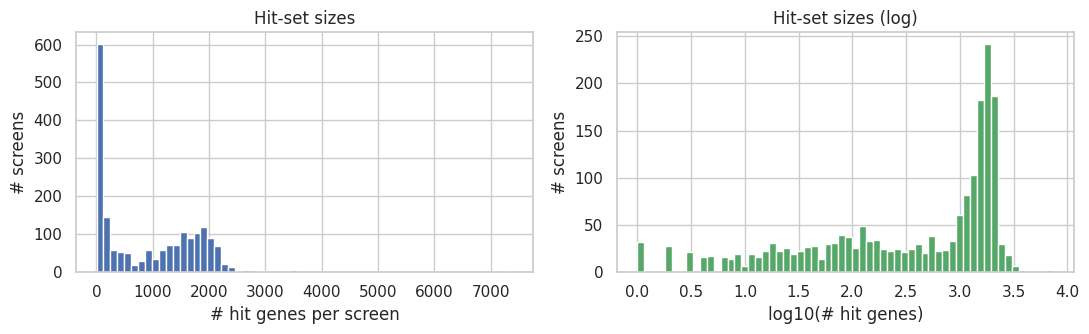

In [3]:
def hit_sets(examples):
    """Return (any_hits, pos_hits, neg_hits) lists of gene-name sets per screen."""
    any_hits, pos_hits, neg_hits = [], [], []
    for e in examples:
        genes = np.asarray(e["relevance_genes"])
        rs = np.asarray(e["relevance_scores"], dtype=float)
        any_hits.append(set(genes[rs != 0].tolist()))
        pos_hits.append(set(genes[rs > 0].tolist()))
        neg_hits.append(set(genes[rs < 0].tolist()))
    return any_hits, pos_hits, neg_hits

any_hits, pos_hits, neg_hits = hit_sets(examples)
meta["n_hits"] = [len(h) for h in any_hits]
meta["n_pos"] = [len(h) for h in pos_hits]
meta["n_neg"] = [len(h) for h in neg_hits]

print("hit-set size  min/median/mean/max: "
      f"{meta.n_hits.min()}/{meta.n_hits.median():.0f}/{meta.n_hits.mean():.0f}/{meta.n_hits.max()}")
print(f"screens with < 3 hits: {(meta.n_hits < 3).sum()}")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(meta.n_hits, bins=60, color="#4C72B0")
ax[0].set(xlabel="# hit genes per screen", ylabel="# screens", title="Hit-set sizes")
ax[1].hist(np.log10(meta.n_hits.clip(lower=1)), bins=60, color="#55A868")
ax[1].set(xlabel="log10(# hit genes)", ylabel="# screens", title="Hit-set sizes (log)")
plt.tight_layout(); plt.savefig(FIGURES / "hitset_sizes.png", dpi=120); plt.show()

We keep every screen (including the ~60 with very few hits): small hit-sets simply produce
low similarity to everything and fall out as their own small communities, which is the correct
behaviour rather than something to filter up front.

## 3. Gene × screen incidence matrix and raw hit-gene Jaccard

We build a sparse binary matrix `B` (genes × screens) and compute the full pairwise Jaccard
from it in one shot:

$$J(A,B) = \frac{|A \cap B|}{|A \cup B|}, \qquad
|A\cap B| = (B^\top B)_{ij}, \quad |A\cup B| = |A| + |B| - |A\cap B|.$$

The intersection counts are a single sparse matrix product — fast even at ~1,900 screens.

In [4]:
def build_incidence(hitsets):
    """Sparse binary genes x screens matrix + gene vocabulary (list)."""
    vocab: dict[str, int] = {}
    rows, cols = [], []
    for j, hs in enumerate(hitsets):
        for g in hs:
            rows.append(vocab.setdefault(g, len(vocab)))
            cols.append(j)
    B = csr_matrix((np.ones(len(rows)), (rows, cols)),
                   shape=(len(vocab), len(hitsets)))
    genes = np.array(list(vocab))
    return B, genes

def jaccard_from_incidence(B, weights=None):
    """Pairwise (weighted) Jaccard over the screen (column) axis of B.

    weights: optional per-gene weight vector (row axis). None -> unweighted.
    """
    if weights is None:
        inter = (B.T @ B).toarray()
        sizes = np.asarray(B.sum(axis=0)).ravel()
    else:
        w = np.asarray(weights, dtype=float)
        inter = (B.T @ (diags(w) @ B)).toarray()
        sizes = (B.T @ w.reshape(-1, 1)).ravel()
    union = sizes[:, None] + sizes[None, :] - inter
    with np.errstate(divide="ignore", invalid="ignore"):
        J = np.where(union > 0, inter / union, 0.0)
    np.fill_diagonal(J, 0.0)
    return J

B, genes = build_incidence(any_hits)
print(f"incidence matrix: {B.shape[0]} genes x {B.shape[1]} screens, nnz={B.nnz:,}")

J_raw = jaccard_from_incidence(B)
iu = np.triu_indices(J_raw.shape[0], 1)
print("raw Jaccard (off-diagonal): "
      f"mean={J_raw[iu].mean():.4f}  median={np.median(J_raw[iu]):.4f}  "
      f"95th pct={np.percentile(J_raw[iu], 95):.4f}  max={J_raw[iu].max():.4f}")

incidence matrix: 21328 genes x 1901 screens, nnz=1,754,503


raw Jaccard (off-diagonal): mean=0.1100  median=0.0116  95th pct=0.5314  max=1.0000


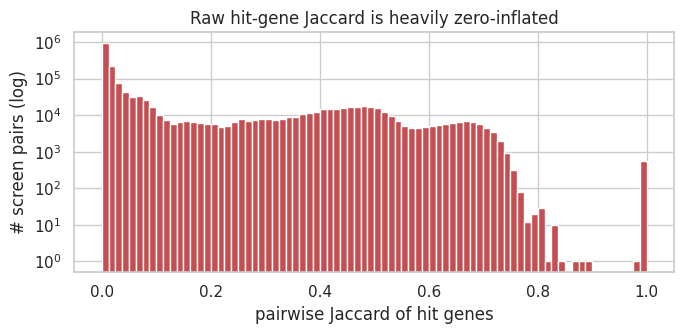

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(J_raw[iu], bins=80, color="#C44E52", log=True)
ax.set(xlabel="pairwise Jaccard of hit genes", ylabel="# screen pairs (log)",
       title="Raw hit-gene Jaccard is heavily zero-inflated")
plt.tight_layout(); plt.savefig(FIGURES / "raw_jaccard_dist.png", dpi=120); plt.show()

**Observation.** The distribution is heavily skewed toward zero (median ≈ 0.01): most screen
pairs share essentially no hits. The non-trivial similarity that *does* exist is inflated by a
small set of **core-essential genes** that recur across most fitness/proliferation screens, so
raw Jaccard conflates "both are viability screens" with "both probe the same biology." We fix
this next.

## 4. IDF-weighted Jaccard — down-weighting ubiquitous essentials

Weight each gene by its inverse document frequency, `idf(g) = log(N / df(g))`, where `df(g)` is
the number of screens in which `g` is a hit. Genes that are hits everywhere (core essentials)
get ~0 weight; genes specific to a few screens dominate the similarity. This is the weighted
(Ruzicka) Jaccard and is our biologically meaningful similarity for clustering.

In [6]:
N = B.shape[1]
df = np.asarray(B.sum(axis=1)).ravel()          # screens per gene
idf = np.log(N / df)                              # rarity weight
J_w = jaccard_from_incidence(B, weights=idf)

print("Most ubiquitous hit genes (lowest IDF, ~core essentials):")
order = np.argsort(df)[::-1]
for i in order[:15]:
    print(f"  {genes[i]:10s}  hit in {int(df[i]):4d}/{N} screens  idf={idf[i]:.2f}")

print("\nIDF-weighted Jaccard (off-diagonal): "
      f"mean={J_w[iu].mean():.4f}  median={np.median(J_w[iu]):.4f}  "
      f"95th pct={np.percentile(J_w[iu], 95):.4f}")

Most ubiquitous hit genes (lowest IDF, ~core essentials):
  EPRS1       hit in  951/1901 screens  idf=0.69
  ATP6V0C     hit in  949/1901 screens  idf=0.69
  PRPF19      hit in  943/1901 screens  idf=0.70
  MYC         hit in  941/1901 screens  idf=0.70
  RPS11       hit in  931/1901 screens  idf=0.71
  RPL11       hit in  931/1901 screens  idf=0.71
  POLR3A      hit in  930/1901 screens  idf=0.71
  AURKB       hit in  923/1901 screens  idf=0.72
  RPS5        hit in  922/1901 screens  idf=0.72
  EEF2        hit in  922/1901 screens  idf=0.72
  PCNA        hit in  920/1901 screens  idf=0.73
  RPS18       hit in  919/1901 screens  idf=0.73
  RPL8        hit in  918/1901 screens  idf=0.73
  PLK1        hit in  918/1901 screens  idf=0.73
  PSMA7       hit in  917/1901 screens  idf=0.73

IDF-weighted Jaccard (off-diagonal): mean=0.0735  median=0.0092  95th pct=0.3667


## 5. Clustering by graph community detection

Because the similarity is sparse (most pairs ≈ 0), hierarchical clustering on the full
distance matrix chains every screen into one giant blob (verified during development). The
right approach is to build a **k-nearest-neighbour similarity graph** — connecting each screen
only to its most-similar peers — and run **Louvain community detection**, which finds groups of
mutually-similar screens and is robust to the sea of near-zero background pairs.

`resolution` controls granularity (higher → more, smaller clusters); `k` sets graph
connectivity. Defaults below were chosen to give interpretable, well-populated clusters.

In [7]:
def knn_graph(S, k=15):
    """Symmetric weighted adjacency: union of each node's top-k similarity edges."""
    n = S.shape[0]
    A = np.zeros_like(S)
    for i in range(n):
        nn = np.argpartition(S[i], -k)[-k:]
        A[i, nn] = S[i, nn]
    A = np.maximum(A, A.T)
    np.fill_diagonal(A, 0.0)
    return A

def louvain_labels(S, k=15, resolution=2.0, seed=SEED):
    A = knn_graph(S, k=k)
    G = nx.from_numpy_array(A)
    comms = louvain_communities(G, weight="weight", resolution=resolution, seed=seed)
    comms = sorted(comms, key=len, reverse=True)   # largest cluster = 0
    labels = np.empty(S.shape[0], dtype=int)
    for cid, nodes in enumerate(comms):
        for n_ in nodes:
            labels[n_] = cid
    return labels

K_NN = 15
RESOLUTION = 2.0
labels = louvain_labels(J_w, k=K_NN, resolution=RESOLUTION)
meta["cluster"] = labels

sizes = pd.Series(labels).value_counts().sort_index()
print(f"{len(sizes)} clusters (k={K_NN}, resolution={RESOLUTION}); "
      f"sizes: {sorted(sizes.tolist(), reverse=True)}")

# modularity as a quality check
A = knn_graph(J_w, k=K_NN)
G = nx.from_numpy_array(A)
comm_sets = [set(np.where(labels == c)[0].tolist()) for c in np.unique(labels)]
print(f"modularity = {nx.algorithms.community.modularity(G, comm_sets, weight='weight'):.3f}")

36 clusters (k=15, resolution=2.0); sizes: [173, 147, 136, 115, 113, 97, 93, 90, 85, 79, 76, 66, 65, 57, 54, 52, 46, 36, 34, 34, 29, 27, 27, 25, 22, 21, 21, 19, 15, 15, 10, 7, 7, 3, 3, 2]
modularity = 0.689


### Cluster-ordered similarity heatmap

Sorting the IDF-weighted similarity matrix by cluster reveals block-diagonal structure — the
visual signature that the communities capture coherent groups of similar screens.

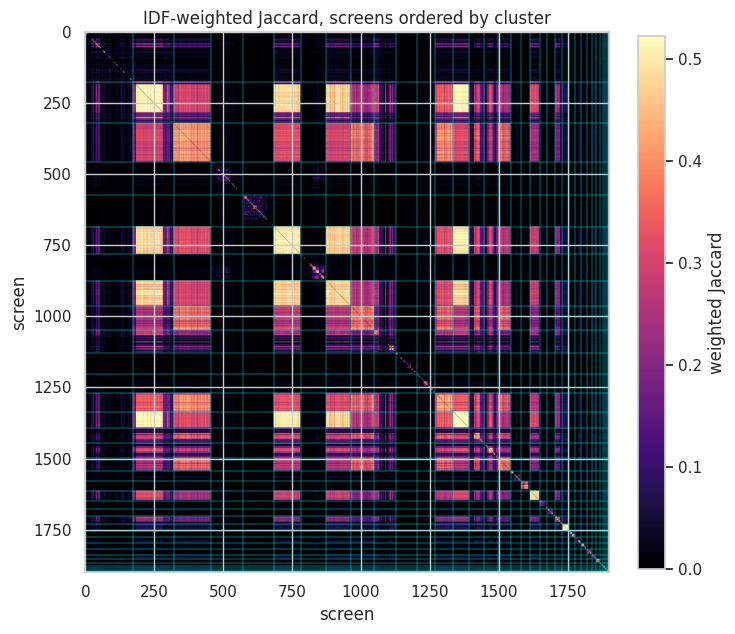

In [8]:
order = np.argsort(labels, kind="stable")
Jo = J_w[np.ix_(order, order)]
fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(Jo, cmap="magma", vmin=0, vmax=np.percentile(J_w[iu], 99), aspect="auto")
# cluster boundaries
bounds = np.cumsum(pd.Series(labels[order]).value_counts(sort=False).sort_index().values)
for b in bounds[:-1]:
    ax.axhline(b, color="cyan", lw=0.3); ax.axvline(b, color="cyan", lw=0.3)
ax.set(title="IDF-weighted Jaccard, screens ordered by cluster",
       xlabel="screen", ylabel="screen")
fig.colorbar(im, ax=ax, fraction=0.046, label="weighted Jaccard")
plt.tight_layout(); plt.savefig(FIGURES / "cluster_heatmap.png", dpi=120); plt.show()

## 6. Name the clusters

Each cluster is summarised and named from three signals:
- its **dominant coarse phenotype** and **tissue/cell type**,
- its **characteristic hit genes** — genes enriched *within* the cluster relative to the whole
  corpus (fraction-of-cluster-screens × IDF), which surface the pathway/biology that binds the
  cluster together.

The auto-generated `name` is a compact, reproducible descriptor; the characteristic genes make
it easy to refine by hand (or with an LLM) into a canonical pathway name.

In [9]:
def characteristic_genes(idx, B, genes, idf, topn=10):
    frac = np.asarray(B[:, idx].mean(axis=1)).ravel()   # fraction of cluster screens hitting gene
    score = frac * idf                                    # specific + prevalent within cluster
    top = np.argsort(score)[::-1][:topn]
    return [genes[i] for i in top if frac[i] > 0]

def short_phen(p):
    return {
        "Fitness / Proliferation / Viability": "Fitness/Viability",
        "Drug / Chemical / Environmental Response": "Drug/Chemical response",
        "Host-Pathogen / Infection Response": "Host-Pathogen/Infection",
        "Molecular Output / Reporter / Pathway Activity": "Reporter/Pathway activity",
        "Trafficking / Localization / Structural Phenotypes": "Trafficking/Structural",
    }.get(p, p)

rows = []
for c in sorted(np.unique(labels)):
    idx = np.where(labels == c)[0]
    ph = collections.Counter(meta.cleaned_phenotype[idx]).most_common(1)[0]
    ce = collections.Counter(meta.cell_type[idx]).most_common(1)[0]
    st = collections.Counter(meta.screen_type[idx]).most_common(1)[0]
    cgenes = characteristic_genes(idx, B, genes, idf, topn=10)
    name = f"{short_phen(ph[0])} · {ce[0].replace(' Cell Line','')} · {', '.join(cgenes[:3])}"
    rows.append({
        "cluster": c,
        "n_screens": len(idx),
        "name": name,
        "dominant_phenotype": ph[0],
        "phenotype_frac": round(ph[1] / len(idx), 2),
        "dominant_cell_type": ce[0],
        "dominant_screen_type": st[0],
        "characteristic_genes": ", ".join(cgenes),
    })

cluster_summary = pd.DataFrame(rows).sort_values("n_screens", ascending=False).reset_index(drop=True)
pd.set_option("display.max_colwidth", 120)
cluster_summary[["cluster", "n_screens", "name", "phenotype_frac"]]

,cluster,n_screens,name,phenotype_frac
0,0,173,"Drug/Chemical response · Lung Adenocarcinoma · NHEJ1, SLC35A2, SBNO2",0.59
1,1,147,"Fitness/Viability · Melanoma · C1QBP, NDUFA10, PET117",0.88
2,2,136,"Fitness/Viability · Cancer · EGR2, TMEM183A, PGAM4",1.00
3,3,115,"Drug/Chemical response · Retinal Pigment Epithelium · PDCD10, NF2, TAOK1",0.89
4,4,113,"Drug/Chemical response · Chronic Myelogenous Leukemia · FBXW7, STUB1, RNF7",0.89
5,5,97,"Fitness/Viability · Cancer · OR5K2, SDC1, NBEAL1",1.00
6,6,93,"Drug/Chemical response · Retinal Pigment Epithelium · E2F7, MAPK1, STAG2",0.78
7,7,90,"Fitness/Viability · Neuroblastoma · GSTT2B, MTRNR2L8, ARGFX",0.99
8,8,85,"Fitness/Viability · Cancer · TCEAL7, LCE1E, PGAM4",1.00
9,9,79,"Fitness/Viability · Acute Myeloid Leukemia · SPDYE5, WASHC1, GOLGA8O",0.71


In [10]:
# full detail
cluster_summary[["cluster", "n_screens", "dominant_phenotype",
                 "dominant_cell_type", "dominant_screen_type", "characteristic_genes"]]

,cluster,n_screens,dominant_phenotype,dominant_cell_type,dominant_screen_type,characteristic_genes
0,0,173,Drug / Chemical / Environmental Response,Lung Adenocarcinoma Cell Line,Positive Selection,"NHEJ1, SLC35A2, SBNO2, MTR, TAOK1, TMEM30A, ARRDC3, XPO4, MECR, USP48"
1,1,147,Fitness / Proliferation / Viability,Melanoma Cell Line,Negative Selection,"C1QBP, NDUFA10, PET117, NDUFA2, MRPL2, MRPS18B, COX5B, NDUFB6, MRPL15, RPUSD3"
2,2,136,Fitness / Proliferation / Viability,Cancer Cell Line,Negative Selection,"EGR2, TMEM183A, PGAM4, LCE1F, LCE1E, GGTLC1, KRTAP5-6, TRAPPC2, KRTAP5-10, KRTAP4-11"
3,3,115,Drug / Chemical / Environmental Response,Retinal Pigment Epithelium Cell Line,bidirectional,"PDCD10, NF2, TAOK1, FRYL, GTF2H5, KIRREL1, KEAP1, TXNDC17, SMAD4, ERCC5"
4,4,113,Drug / Chemical / Environmental Response,Chronic Myelogenous Leukemia Cell Line,bidirectional,"FBXW7, STUB1, RNF7, CNOT4, ZBTB14, RNF19B, UBE4B, ZBTB10, SMURF1, MIB1"
5,5,97,Fitness / Proliferation / Viability,Cancer Cell Line,Negative Selection,"OR5K2, SDC1, NBEAL1, GSDMA, GALP, GJA3, OR1D2, OR1J1, OR7A17, HAMP"
6,6,93,Drug / Chemical / Environmental Response,Retinal Pigment Epithelium Cell Line,bidirectional,"E2F7, MAPK1, STAG2, DYRK1A, NF2, ITGA5, PTEN, EME1, RAD51B, CYB5R4"
7,7,90,Fitness / Proliferation / Viability,Neuroblastoma Cell Line,Negative Selection,"GSTT2B, MTRNR2L8, ARGFX, OR11H1, OR4F4, TMED7, RBAK-RBAKDN, ANKRD20A2P, FAM72B, ZNF816-ZNF321P"
8,8,85,Fitness / Proliferation / Viability,Cancer Cell Line,Negative Selection,"TCEAL7, LCE1E, PGAM4, KRTAP5-10, KRTAP5-6, VCY, LDHA, H2BC9, LCE1F, KRTAP4-11"
9,9,79,Fitness / Proliferation / Viability,Acute Myeloid Leukemia Cell Line,Negative Selection,"SPDYE5, WASHC1, GOLGA8O, GOLGA6L4, POLR2J2, HSD17B10, REXO1L1P, SRGAP2B, PPCDC, DUX4L8"


### Cluster composition by phenotype

How the coarse phenotype categories distribute across clusters — most clusters are dominated by
one phenotype, confirming the communities are biologically coherent rather than arbitrary.

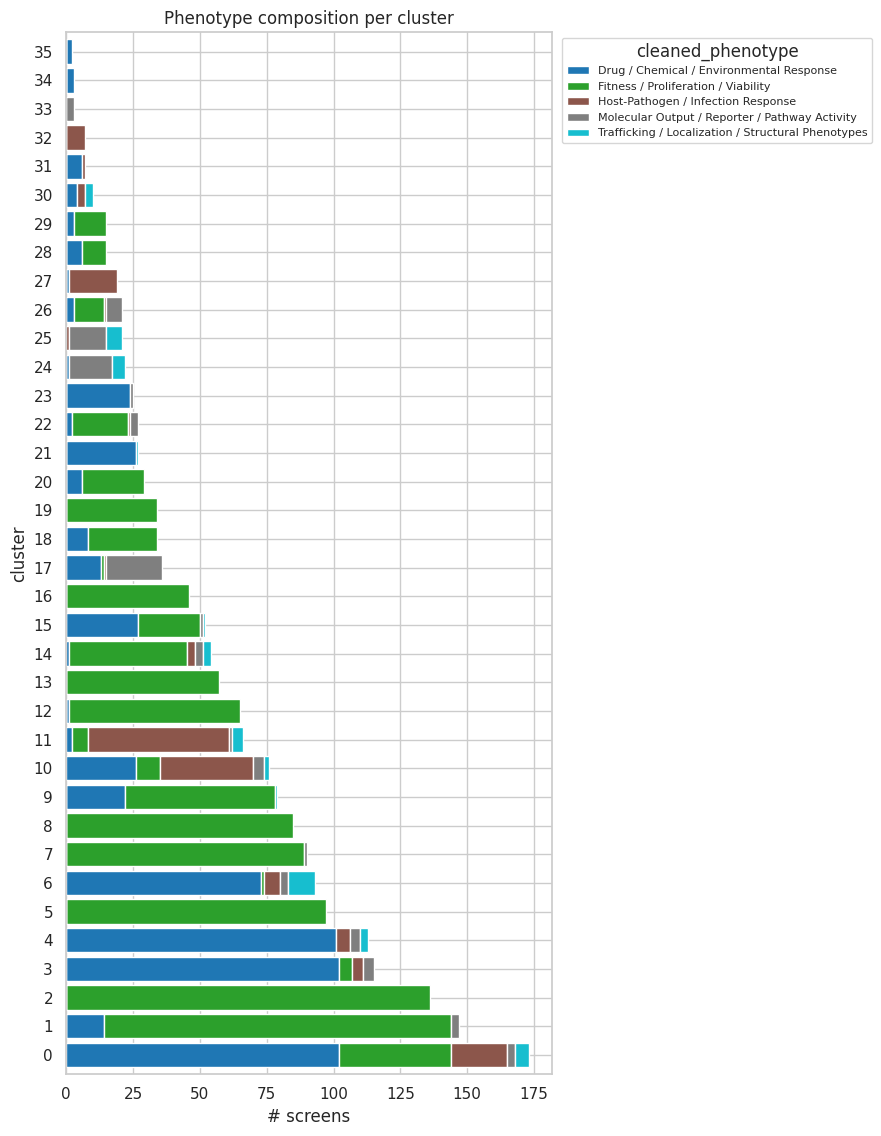

In [11]:
comp = (meta.groupby(["cluster", "cleaned_phenotype"]).size()
        .unstack(fill_value=0))
comp = comp.loc[cluster_summary.cluster]  # order by size
ax = comp.plot(kind="barh", stacked=True, figsize=(9, max(4, 0.32 * len(comp))),
               colormap="tab10", width=0.85)
ax.set(xlabel="# screens", ylabel="cluster", title="Phenotype composition per cluster")
ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=8, title="cleaned_phenotype")
plt.tight_layout(); plt.savefig(FIGURES / "cluster_phenotype_composition.png", dpi=120); plt.show()

### 2-D embedding (UMAP) of screens coloured by cluster

A UMAP layout of the IDF-weighted similarity (as a precomputed distance) gives an intuitive map
of the screen landscape.

/cv/home/wua33/conda/gnesys/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/cv/home/wua33/conda/gnesys/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


/cv/home/wua33/conda/gnesys/lib/python3.11/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(


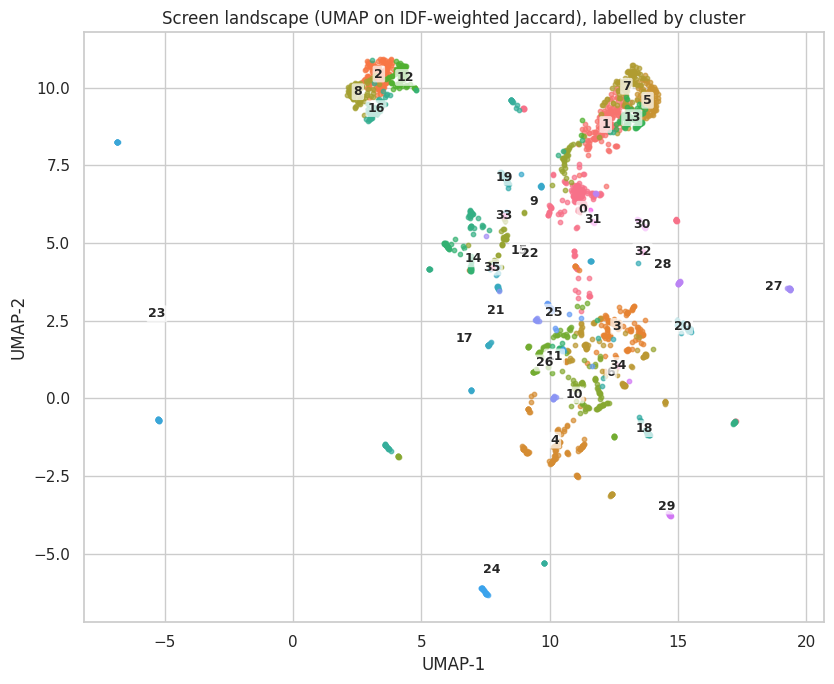

In [12]:
import umap

D_w = 1.0 - J_w
np.fill_diagonal(D_w, 0.0)
D_w = np.clip((D_w + D_w.T) / 2, 0, None)

reducer = umap.UMAP(metric="precomputed", n_neighbors=15, min_dist=0.1,
                    random_state=SEED)
emb = reducer.fit_transform(D_w)

fig, ax = plt.subplots(figsize=(8.5, 7))
n_clusters = len(np.unique(labels))
palette = sns.color_palette("husl", n_clusters)
for c in cluster_summary.cluster:
    m = labels == c
    ax.scatter(emb[m, 0], emb[m, 1], s=10, color=palette[c % n_clusters], alpha=0.7)
    cx, cy = emb[m, 0].mean(), emb[m, 1].mean()
    ax.text(cx, cy, str(c), fontsize=9, fontweight="bold",
            ha="center", va="center",
            bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7))
ax.set(title="Screen landscape (UMAP on IDF-weighted Jaccard), labelled by cluster",
       xlabel="UMAP-1", ylabel="UMAP-2")
plt.tight_layout(); plt.savefig(FIGURES / "umap_clusters.png", dpi=120); plt.show()

## 7. Save results

Persist the per-screen cluster assignments, the cluster summary/naming table, and the
similarity matrices for downstream use.

In [13]:
meta_out = meta.copy()
meta_out = meta_out.merge(cluster_summary[["cluster", "name"]], on="cluster", how="left")
meta_out.to_csv(RESULTS / "screen_cluster_assignments.csv", index=True)
cluster_summary.to_csv(RESULTS / "cluster_summary.csv", index=False)
np.savez_compressed(RESULTS / "similarity_matrices.npz",
                    jaccard_raw=J_raw.astype(np.float32),
                    jaccard_idf=J_w.astype(np.float32),
                    labels=labels,
                    screen_names=meta.dataset_name.to_numpy())
print("saved:")
for p in sorted(RESULTS.glob("*")):
    print("  ", p, f"({p.stat().st_size/1e3:.0f} KB)")

saved:
   results/cluster_summary.csv (9 KB)
   results/screen_cluster_assignments.csv (601 KB)
   results/similarity_matrices.npz (14934 KB)


## 8. Summary, caveats & next steps

**What we did.** Defined hit-gene sets per screen, measured pairwise **Jaccard** similarity,
corrected for core-essential dominance with an **IDF-weighted Jaccard**, and grouped the 1,901
main-dataset screens into biologically coherent communities via **Louvain** on a k-NN similarity
graph — each cluster named from its dominant phenotype/tissue and characteristic genes.

**Sanity checks.** The cluster-ordered heatmap shows clear block structure; positive-control
clusters emerge with textbook marker genes (e.g. ACE2/TMPRSS2 → coronavirus entry;
JAK/STAT/B2M → interferon–antigen presentation; ATG/WIPI/BECN1 → autophagy;
NDUFA/MRPL/MRPS → mitochondrial/OXPHOS fitness; PFKP/G6PD/GPI → glycolysis).

**Caveats.**
- Similarity is defined purely on **hit-gene overlap**; it ignores effect-size magnitude and
  the graded relevance scores. Two screens with the same hits at different strengths look
  identical here.
- Jaccard depends on the hit threshold baked into the dataset (the ±relevance definition) and on
  library overlap — screens with disjoint gene libraries can never share hits regardless of
  biology.
- `resolution` / `k` are tunable; the specific cluster count is not canonical. Re-run the sweep
  to pick granularity for a given use.

**Next steps.**
- **Directional Jaccard**: cluster on signed hits (`pos_hits` vs `neg_hits`) to separate
  enrichment- from depletion-driven biology in bidirectional screens.
- **Rank/score-aware similarity**: RBO or weighted-cosine on the graded relevance scores.
- **Pathway enrichment** (GO / Reactome via the `reactome`/`string` skills) on each cluster's
  characteristic genes to assign formal pathway names.
- **LLM naming**: feed characteristic genes + metadata to a Claude model for a canonical,
  human-readable cluster label.
- **Library-overlap control**: restrict Jaccard to the intersection of screen libraries, or
  normalise by expected overlap, to remove the library-composition confound.